<a href="https://colab.research.google.com/github/danhhuit/deep_learning_practice/blob/main/Labs02_Reduction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## REGRESSION
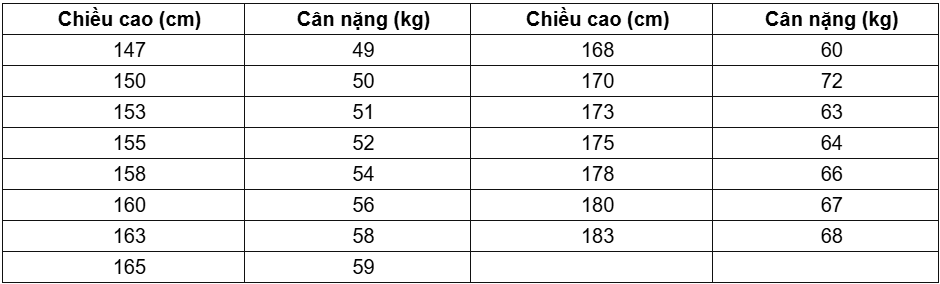

In [19]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model

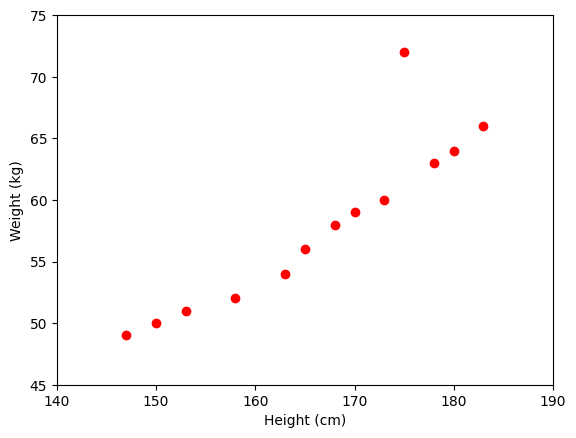

In [20]:
# height (cm), weight (kg)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
Y = np.array([[49, 50, 51, 52, 54, 56, 58, 59, 60, 72, 63, 64, 66]]).T
# visualize data
plt.plot(X, Y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

w =  [[-31.03242177]
 [  0.53510008]]


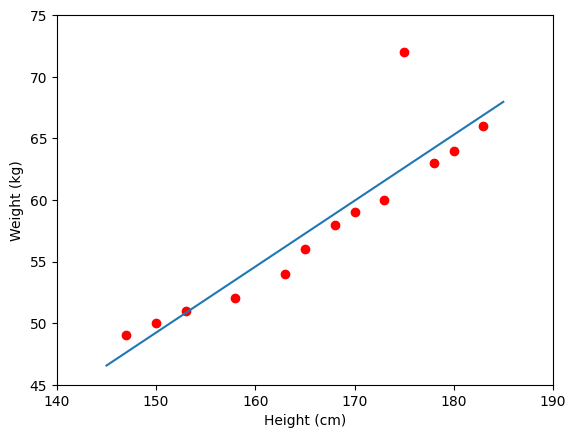

In [21]:
# Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, Y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)

# Preparing the fititng line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line
plt.plot(X.T, Y.T, 'ro')
plt.plot(x0, y0)
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

In [22]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0
print('Predict weight of person with height 155 cm: %.2f (kg), Predict weight of person with height 160 cm: %.2f (kg)' % (y1, y2))

Predict weight of person with height 155 cm: 51.91 (kg), Predict weight of person with height 160 cm: 54.58 (kg)


In [23]:
regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(Xbar, Y)

# Compare two results
print('Solution found by scikit-learn  : ', regr.coef_)
print('Solution found by (5): ', w.T)

Solution found by scikit-learn  :  [[-31.03242176   0.53510008]]
Solution found by (5):  [[-31.03242177   0.53510008]]


## ANN (ARTIFICAL NEURAL NETWORK)

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf

import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, cross_validate

In [18]:
pip install scikeras

In [25]:
fashion = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion.load_data()
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [26]:
X_train = train_images.reshape(60000, 784)
X_test = test_images.reshape(10000, 784)

minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes: ', len(np.unique(train_labels)))
print('Classes: ', np.unique(train_labels))


Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


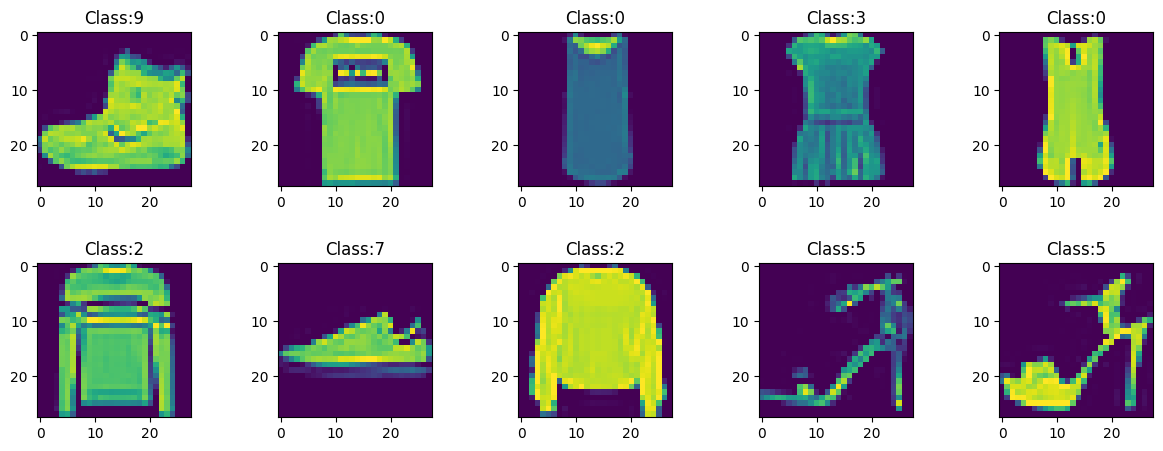

In [27]:
import matplotlib.pyplot as plt

# Data visualization
fig, axes = plt.subplots(nrows = 2, ncols = 5, figsize = (15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(train_images[i].reshape(28, 28))
  ax[i].title.set_text('Class:' + str(train_labels[i]))
plt.subplots_adjust(hspace = 0.5)
plt.show()

In [28]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Input # Import Input layer

fashion_model = Sequential([
    Input(shape=(X_train.shape[1],)), # Explicitly define input layer
    Dense(units = 256, activation = 'relu', kernel_initializer='uniform'),
    Dense(units=10, kernel_initializer='uniform', activation = 'softmax')
])
fashion_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
fashion_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model_fit = fashion_model.fit(X_train, train_labels, epochs = 20, verbose = 1, validation_split = 0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.8224 - loss: 0.5027 - val_accuracy: 0.8525 - val_loss: 0.4152
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8665 - loss: 0.3678 - val_accuracy: 0.8653 - val_loss: 0.3689
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8761 - loss: 0.3340 - val_accuracy: 0.8563 - val_loss: 0.3955
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8861 - loss: 0.3090 - val_accuracy: 0.8752 - val_loss: 0.3426
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8922 - loss: 0.2910 - val_accuracy: 0.8813 - val_loss: 0.3294
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8983 - loss: 0.2737 - val_accuracy: 0.8808 - val_loss: 0.3387
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9039 - loss: 0.2586 - val_accuracy: 0.8822 - val_loss: 0.3161
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9075 - loss: 0.

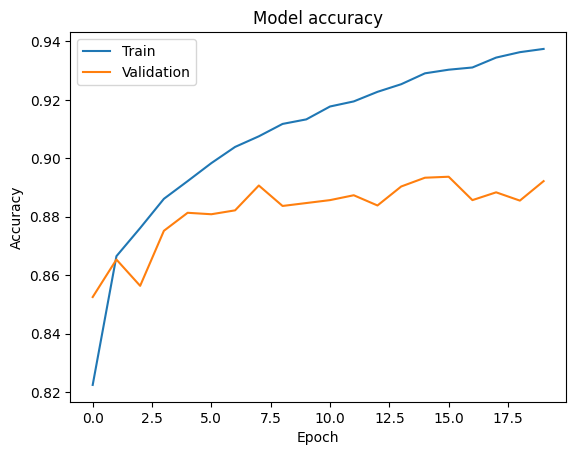

In [30]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

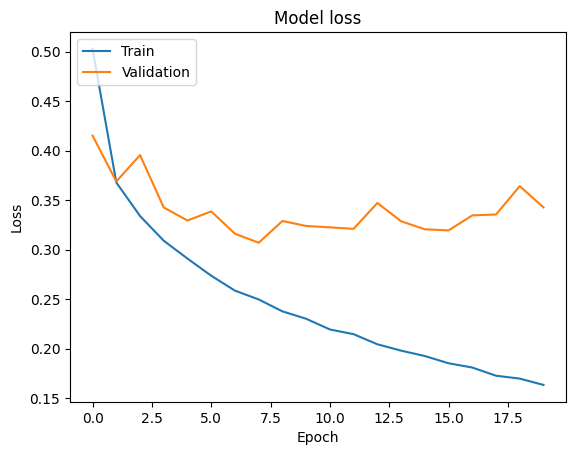

In [31]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [32]:
print(np.argmax(fashion_model.predict(X_test)[0]), test_labels[0])
print(np.argmax(fashion_model.predict(X_test)[10]), test_labels[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [33]:
mnist_train_path = '/content/fashion-mnist_train.csv'
mnist_test_path = '/content/fashion-mnist_train.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [34]:
X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]
print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))

(60000, 784)
Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


In [35]:
model = Sequential()
model.add(Dense(input_dim = X_train.shape[1], units = 256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units = 10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model_fit = model.fit(X_train, y_train, epochs = 30, verbose = 1)
print(np.argmax(model.predict(X_test)[0]), y_test[0])

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7902 - loss: 1.0140
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.8248 - loss: 0.5026
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8299 - loss: 0.4987
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8372 - loss: 0.4789
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8391 - loss: 0.4760
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8427 - loss: 0.4642
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8468 - loss: 0.4519
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8470 - loss: 0.4482
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8491 - loss: 0.4447
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8523 - loss: 0.4384
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8520 - loss: 0.4348
Epoch 12/30
1875/18

In [37]:
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress.jpg',
    color_mode = 'grayscale',
    target_size = img_size
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
# print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)
score =np.argmax(img_predict)
print(score)


(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  4.2573592e-10 0.0000000e+00 1.2159536e-10 0.0000000e+00 1.0000000e+00]]
9


In [39]:
import kagglehub
path = kagglehub.dataset_download("pankrzysiu/cifar10-python")

Using Colab cache for faster access to the 'cifar10-python' dataset.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Kích thước tập train: (50000, 32, 32, 3)
Kích thước tập test : (10000, 32, 32, 3)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,811,594 (14.54 MB)

 Trainable params: 3,808,522 (14.53 MB)

 Non-trainable params: 3,072 (12.00 KB)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.3162 - loss: 1.9884 - val_accuracy: 0.3507 - val_loss: 1.8480
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.3927 - loss: 1.7143 - val_accuracy: 0.3085 - val_loss: 1.9334
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.4182 - loss: 1.6239 - val_accuracy: 0.3393 - val_loss: 1.8046
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.4335 - loss: 1.5788 - val_accuracy: 0.3860 - val_loss: 1.7033
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.4464 - loss: 1.5528 - val_accuracy: 0.3708 - val_loss: 1.7127
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.4535 - loss: 1.5272 - val_accuracy: 0.3815 - val_loss: 1.7365
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 88ms/step - accuracy: 0.4559 - loss: 1.5204 - val_accuracy: 0.4415 - val_loss: 1.5826
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.4577 - loss: 1.5140 - 

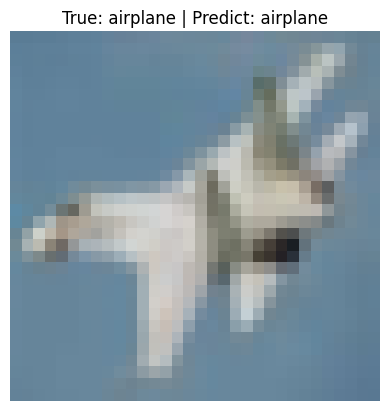

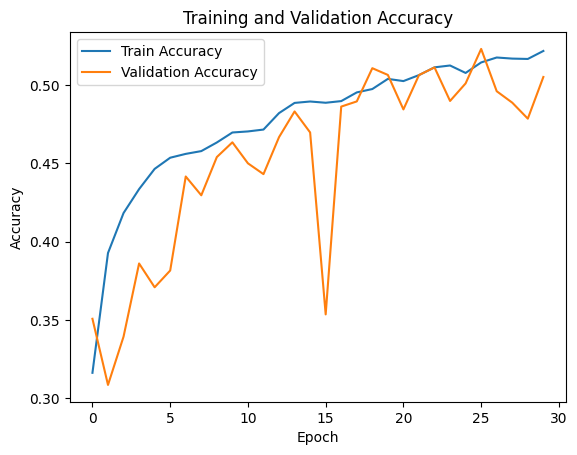

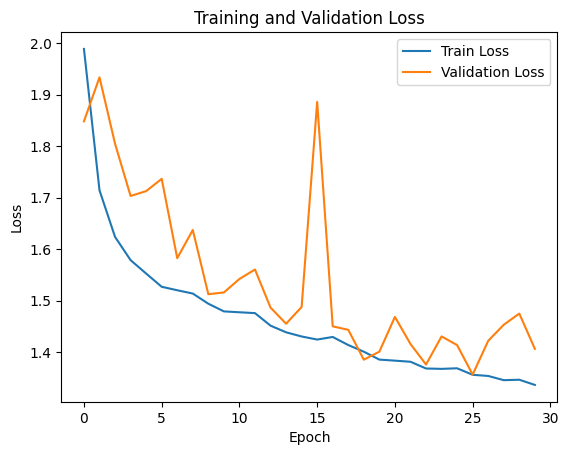

In [40]:
# ann_cifar10.py

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# =========================
# 1. Khai báo nhãn CIFAR-10
# =========================
class_names = [
    "airplane",    # 0
    "automobile",  # 1
    "bird",        # 2
    "cat",         # 3
    "deer",        # 4
    "dog",         # 5
    "frog",        # 6
    "horse",       # 7
    "ship",        # 8
    "truck"        # 9
]

# =========================
# 2. Load dataset CIFAR-10
# =========================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Kích thước tập train:", x_train.shape)
print("Kích thước tập test :", x_test.shape)

# Chuyển y từ dạng [[1], [5], ...] về [1, 5, ...]
y_train = y_train.flatten()
y_test = y_test.flatten()

# =========================
# 3. Tiền xử lý dữ liệu
# =========================
# Ảnh CIFAR-10 có giá trị pixel từ 0 đến 255
# Chuẩn hóa về khoảng [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# =========================
# 4. Xây dựng mô hình ANN
# =========================
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # ANN không dùng Convolution nên cần Flatten ảnh thành vector
    layers.Flatten(),

    layers.Dense(1024, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),

    # 10 lớp tương ứng 10 nhãn CIFAR-10
    layers.Dense(10, activation="softmax")
])

# =========================
# 5. Compile mô hình
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 6. Huấn luyện mô hình
# =========================
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "best_ann_cifar10_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

# =========================
# 7. Đánh giá mô hình
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test)

print("\nKết quả đánh giá trên tập test:")
print("Test loss    :", test_loss)
print("Test accuracy:", test_acc)

# =========================
# 8. Dự đoán thử một ảnh
# =========================
index = 10

image = x_test[index]
true_label = y_test[index]

prediction = model.predict(np.expand_dims(image, axis=0))
predicted_label = np.argmax(prediction)

print("\nDự đoán ảnh thử nghiệm:")
print("Nhãn thật :", class_names[true_label])
print("Nhãn đoán :", class_names[predicted_label])

plt.imshow(image)
plt.title(
    f"True: {class_names[true_label]} | Predict: {class_names[predicted_label]}"
)
plt.axis("off")
plt.show()

# =========================
# 9. Vẽ biểu đồ Accuracy và Loss
# =========================
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()